# ⚙️ Notebook 3: Ingeniería de Características
## Dataset: Medical Cost Personal Dataset

**Objetivo:** Seleccionar las características más relevantes usando métodos estadísticos y de importancia de features, para mejorar el desempeño de los modelos y reducir overfitting.

**Métodos utilizados:**
1. Correlación de Pearson y Spearman
2. Mutual Information (MI)
3. Prueba F (SelectKBest)
4. Importancia basada en Random Forest
5. Análisis de varianza (eliminación de baja varianza)
6. Selección final y guardado

In [2]:
# ─────────────────────────────────────────
# IMPORTACIONES
# ─────────────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.feature_selection import (
    SelectKBest, f_regression, mutual_info_regression,
    VarianceThreshold, RFE
)
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
import joblib
import json
import warnings
warnings.filterwarnings('ignore')

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
np.random.seed(42)
print('✅ Librerías importadas correctamente')

✅ Librerías importadas correctamente


## 1. Carga de Datos Preprocesados

In [3]:
# Cargar datasets del notebook anterior
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()
X_train_scaled = pd.read_csv('../data/processed/X_train_scaled.csv')
X_test_scaled  = pd.read_csv('../data/processed/X_test_scaled.csv')

with open('../data/processed/feature_info.json') as f:
    feature_info = json.load(f)

print(f'📦 X_train shape: {X_train.shape}')
print(f'📦 X_test shape:  {X_test.shape}')
print(f'📋 Features totales: {len(feature_info["all_features"])}')
print(f'🎯 Target: {feature_info["target"]}')
print('\nFeatures disponibles:')
for f in feature_info['all_features']:
    print(f'  - {f}')

📦 X_train shape: (1069, 19)
📦 X_test shape:  (268, 19)
📋 Features totales: 19
🎯 Target: log_charges

Features disponibles:
  - age
  - bmi
  - children
  - bmi_smoker
  - age_smoker
  - smoker_enc
  - sex_female
  - sex_male
  - region_northeast
  - region_northwest
  - region_southeast
  - region_southwest
  - bmi_category_underweight
  - bmi_category_normal
  - bmi_category_overweight
  - bmi_category_obese
  - age_group_young
  - age_group_middle
  - age_group_senior


## 2. Eliminación de Baja Varianza

📊 Varianza por Feature (descendente):
age_smoker                  271.7040
age                         195.7773
bmi_smoker                  154.5259
bmi                          36.5905
children                      1.4260
sex_female                    0.2498
sex_male                      0.2498
bmi_category_obese            0.2494
age_group_senior              0.2337
age_group_young               0.2221
age_group_middle              0.2078
bmi_category_overweight       0.2067
region_southeast              0.1964
region_southwest              0.1864
region_northwest              0.1860
region_northeast              0.1807
smoker_enc                    0.1601
bmi_category_normal           0.1413
bmi_category_underweight      0.0138

⚠️ Features con baja varianza (< 0.01): []


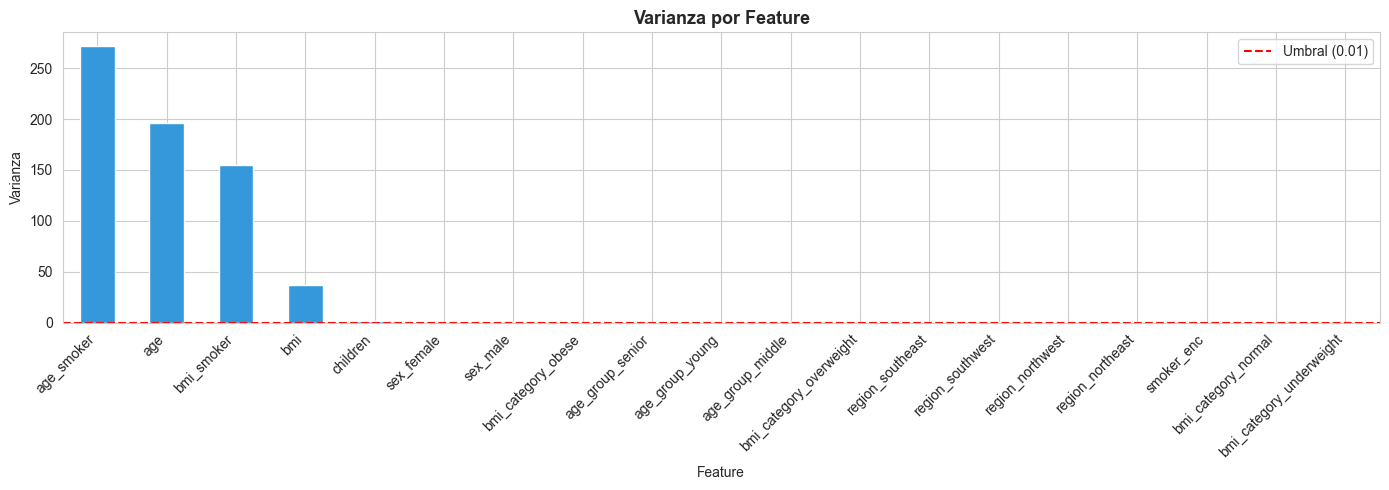

In [4]:
# ─────────────────────────────────────────
# VARIANCE THRESHOLD
# Elimina features con varianza casi nula
# ─────────────────────────────────────────
vt = VarianceThreshold(threshold=0.01)
vt.fit(X_train)

variances = pd.Series(vt.variances_, index=X_train.columns).sort_values(ascending=False)

print('📊 Varianza por Feature (descendente):')
print(variances.round(4).to_string())

low_var_features = variances[variances < 0.01].index.tolist()
print(f'\n⚠️ Features con baja varianza (< 0.01): {low_var_features}')

# Visualización
fig, ax = plt.subplots(figsize=(14, 5))
variances.plot(kind='bar', ax=ax, color='#3498db', edgecolor='white')
ax.axhline(y=0.01, color='red', linestyle='--', label='Umbral (0.01)')
ax.set_title('Varianza por Feature', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('Varianza')
ax.legend()
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/feature_variance.png', dpi=150)
plt.show()

## 3. Correlación con el Target

📊 CORRELACIÓN CON EL TARGET (|r|):
                          Pearson  Spearman  Promedio
bmi_smoker                 0.6712    0.6618    0.6665
smoker_enc                 0.6533    0.6533    0.6533
age_smoker                 0.6300    0.6545    0.6422
age                        0.5182    0.5217    0.5199
age_group_senior           0.4262    0.4597    0.4430
age_group_young            0.4210    0.3881    0.4046
children                   0.1741    0.1431    0.1586
bmi                        0.1228    0.1102    0.1165
bmi_category_obese         0.1235    0.1059    0.1147
bmi_category_underweight   0.0793    0.0740    0.0766
bmi_category_normal        0.0734    0.0557    0.0645
bmi_category_overweight    0.0545    0.0511    0.0528
age_group_middle           0.0168    0.0862    0.0515
region_northeast           0.0417    0.0450    0.0433
region_southwest           0.0383    0.0371    0.0377
region_northwest           0.0261    0.0287    0.0274
region_southeast           0.0228    0.0210    

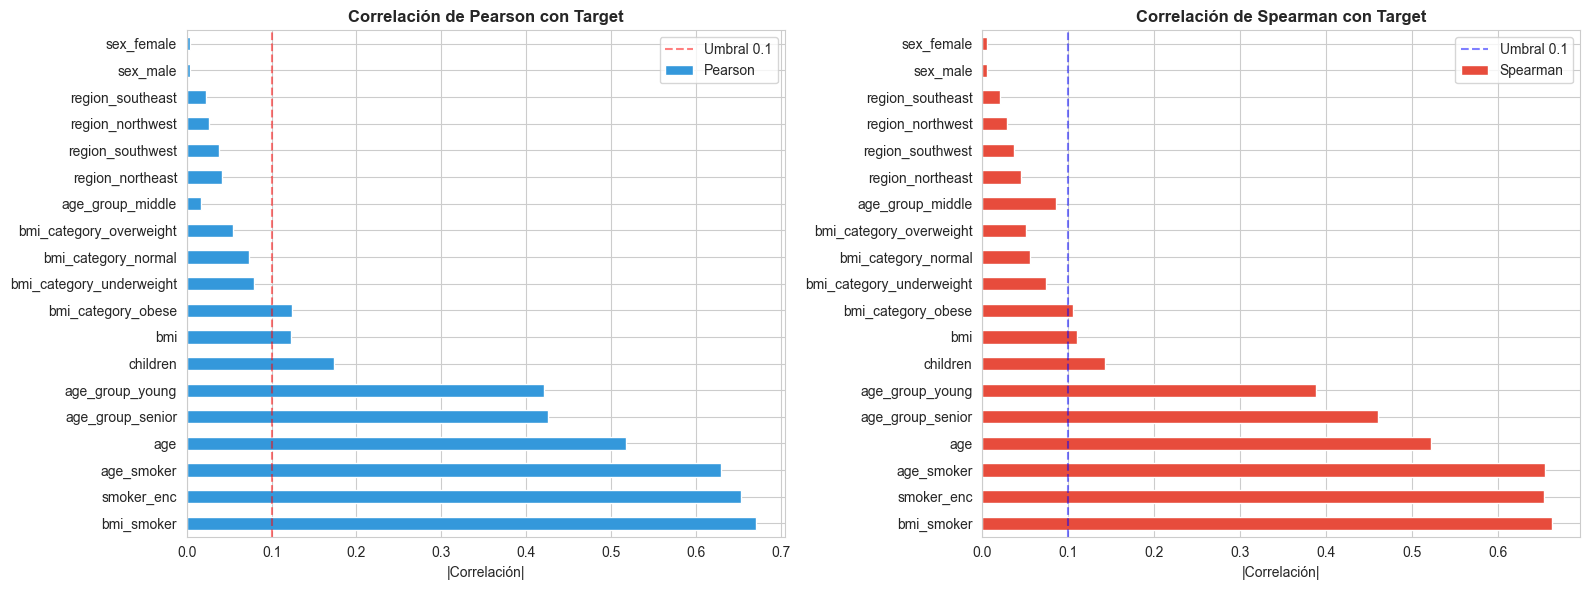

In [5]:
# ─────────────────────────────────────────
# CORRELACIÓN DE PEARSON Y SPEARMAN
# ─────────────────────────────────────────
df_train = X_train.copy()
df_train['target'] = y_train.values

pearson_corr = df_train.corr()['target'].drop('target').abs().sort_values(ascending=False)
spearman_corr = df_train.corr(method='spearman')['target'].drop('target').abs().sort_values(ascending=False)

corr_df = pd.DataFrame({'Pearson': pearson_corr, 'Spearman': spearman_corr})
corr_df['Promedio'] = corr_df.mean(axis=1)
corr_df = corr_df.sort_values('Promedio', ascending=False)

print('📊 CORRELACIÓN CON EL TARGET (|r|):')
print(corr_df.round(4).to_string())

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

corr_df['Pearson'].plot(kind='barh', ax=axes[0], color='#3498db', edgecolor='white')
axes[0].set_title('Correlación de Pearson con Target', fontweight='bold')
axes[0].set_xlabel('|Correlación|')
axes[0].axvline(x=0.1, color='red', linestyle='--', alpha=0.5, label='Umbral 0.1')
axes[0].legend()

corr_df['Spearman'].plot(kind='barh', ax=axes[1], color='#e74c3c', edgecolor='white')
axes[1].set_title('Correlación de Spearman con Target', fontweight='bold')
axes[1].set_xlabel('|Correlación|')
axes[1].axvline(x=0.1, color='blue', linestyle='--', alpha=0.5, label='Umbral 0.1')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/correlation_with_target.png', dpi=150)
plt.show()

## 4. Mutual Information

📊 MUTUAL INFORMATION SCORES:
age                         1.4369
bmi_smoker                  0.5121
age_smoker                  0.5030
age_group_senior            0.4358
age_group_young             0.3695
smoker_enc                  0.3510
age_group_middle            0.3304
children                    0.1575
sex_male                    0.1366
sex_female                  0.1366
bmi_category_obese          0.0969
bmi                         0.0645
region_northeast            0.0480
region_northwest            0.0429
bmi_category_overweight     0.0400
bmi_category_normal         0.0361
region_southeast            0.0281
region_southwest            0.0146
bmi_category_underweight    0.0003


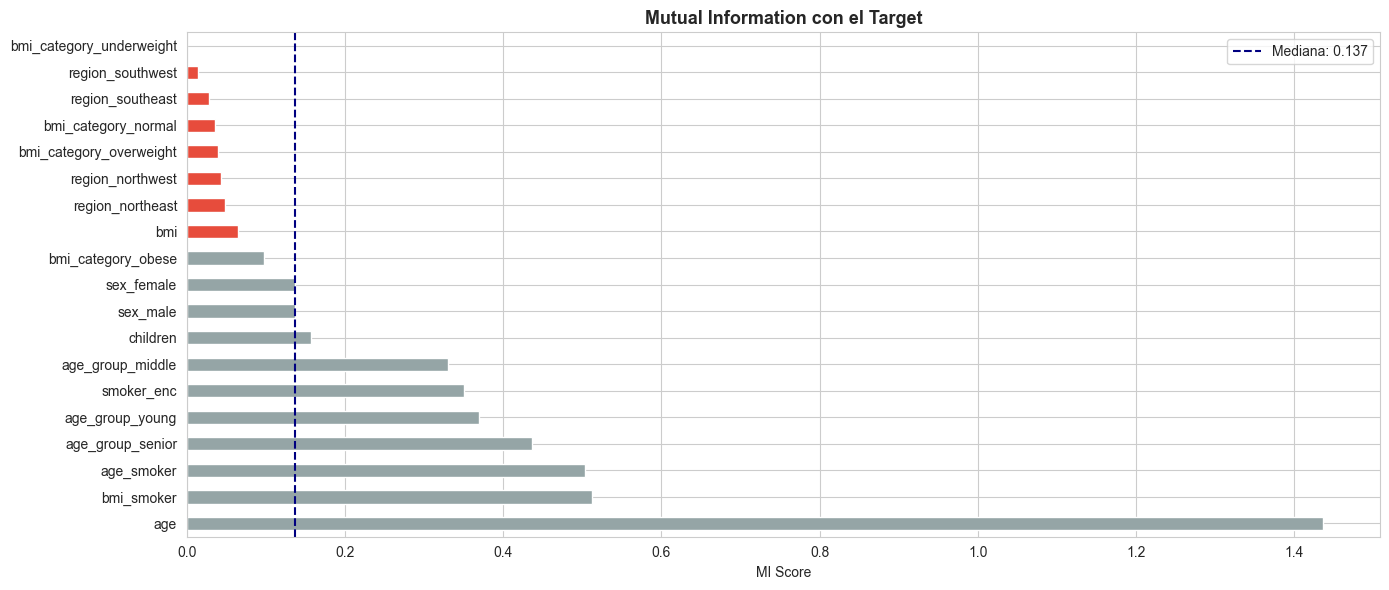

In [6]:
# ─────────────────────────────────────────
# MUTUAL INFORMATION REGRESSION
# Captura relaciones no lineales
# ─────────────────────────────────────────
mi_scores = mutual_info_regression(X_train, y_train, random_state=42)
mi_series = pd.Series(mi_scores, index=X_train.columns).sort_values(ascending=False)

print('📊 MUTUAL INFORMATION SCORES:')
print(mi_series.round(4).to_string())

# Visualización
fig, ax = plt.subplots(figsize=(14, 6))
colors = ['#e74c3c' if v > mi_series.median() else '#95a5a6' for v in mi_series.values]
mi_series.plot(kind='barh', ax=ax, color=colors[::-1], edgecolor='white')
ax.set_title('Mutual Information con el Target', fontsize=13, fontweight='bold')
ax.set_xlabel('MI Score')
ax.axvline(x=mi_series.median(), color='navy', linestyle='--', 
           label=f'Mediana: {mi_series.median():.3f}')
ax.legend()
plt.tight_layout()
plt.savefig('../data/processed/mutual_information.png', dpi=150)
plt.show()

## 5. Prueba F (SelectKBest)

In [7]:
# ─────────────────────────────────────────
# SELECT K BEST — Prueba F
# ─────────────────────────────────────────
skb = SelectKBest(score_func=f_regression, k='all')
skb.fit(X_train, y_train)

f_scores = pd.DataFrame({
    'F_Score': skb.scores_,
    'P_Value': skb.pvalues_
}, index=X_train.columns).sort_values('F_Score', ascending=False)

f_scores['Significativa'] = f_scores['P_Value'] < 0.05

print('📊 PRUEBA F (SelectKBest):')
print(f_scores.round(4).to_string())

sig_features = f_scores[f_scores['Significativa']].index.tolist()
print(f'\n✅ Features estadísticamente significativas (p < 0.05): {len(sig_features)}')
print(sig_features)

📊 PRUEBA F (SelectKBest):
                           F_Score  P_Value  Significativa
bmi_smoker                874.9669   0.0000           True
smoker_enc                794.6149   0.0000           True
age_smoker                702.0371   0.0000           True
age                       391.7400   0.0000           True
age_group_senior          236.9024   0.0000           True
age_group_young           229.8413   0.0000           True
children                   33.3428   0.0000           True
bmi_category_obese         16.5262   0.0001           True
bmi                        16.3412   0.0001           True
bmi_category_underweight    6.7446   0.0095           True
bmi_category_normal         5.7737   0.0164           True
bmi_category_overweight     3.1806   0.0748          False
region_northeast            1.8579   0.1732          False
region_southwest            1.5692   0.2106          False
region_northwest            0.7297   0.3932          False
region_southeast            0.

## 6. Importancia con Random Forest

📊 IMPORTANCIA POR RANDOM FOREST:
  age                                : 37.09%  ██████████████████
  bmi_smoker                         : 30.89%  ███████████████
  age_smoker                         :  8.30%  ████
  bmi                                :  7.67%  ███
  children                           :  5.21%  ██
  smoker_enc                         :  4.97%  ██
  region_northeast                   :  0.90%  
  region_northwest                   :  0.81%  
  sex_male                           :  0.72%  
  sex_female                         :  0.68%  
  region_southeast                   :  0.63%  
  region_southwest                   :  0.52%  
  bmi_category_normal                :  0.42%  
  bmi_category_overweight            :  0.39%  
  bmi_category_obese                 :  0.33%  
  age_group_middle                   :  0.19%  
  age_group_senior                   :  0.13%  
  age_group_young                    :  0.10%  
  bmi_category_underweight           :  0.04%  


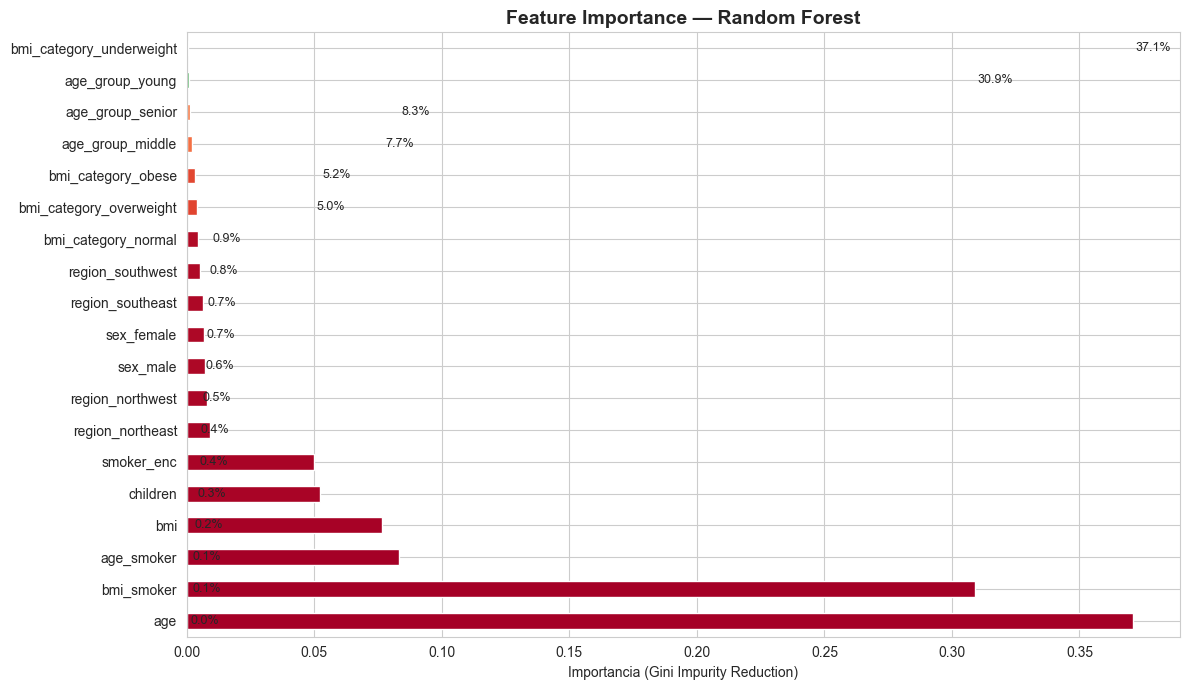

In [8]:
# ─────────────────────────────────────────
# RANDOM FOREST FEATURE IMPORTANCE
# ─────────────────────────────────────────
rf_selector = RandomForestRegressor(n_estimators=200, random_state=42, n_jobs=-1)
rf_selector.fit(X_train, y_train)

rf_importance = pd.Series(
    rf_selector.feature_importances_,
    index=X_train.columns
).sort_values(ascending=False)

rf_importance_pct = (rf_importance / rf_importance.sum() * 100).round(2)

print('📊 IMPORTANCIA POR RANDOM FOREST:')
for feat, imp in rf_importance_pct.items():
    bar = '█' * int(imp / 2)
    print(f'  {feat:35s}: {imp:5.2f}%  {bar}')

# Visualización
fig, ax = plt.subplots(figsize=(12, 7))
colors = plt.cm.RdYlGn(rf_importance.values / rf_importance.max())
rf_importance.plot(kind='barh', ax=ax, color=colors[::-1], edgecolor='white')
ax.set_title('Feature Importance — Random Forest', fontsize=14, fontweight='bold')
ax.set_xlabel('Importancia (Gini Impurity Reduction)')

# Añadir porcentajes
for i, (val, feat) in enumerate(zip(rf_importance.values[::-1], rf_importance.index[::-1])):
    ax.text(val + 0.001, i, f'{val*100:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('../data/processed/rf_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

## 7. Selección con LASSO

📊 LASSO con alpha=0.001:
   Features con coef ≠ 0: 17
   Features eliminadas (coef=0): 2
   Features eliminadas: ['sex_male', 'age_group_young']


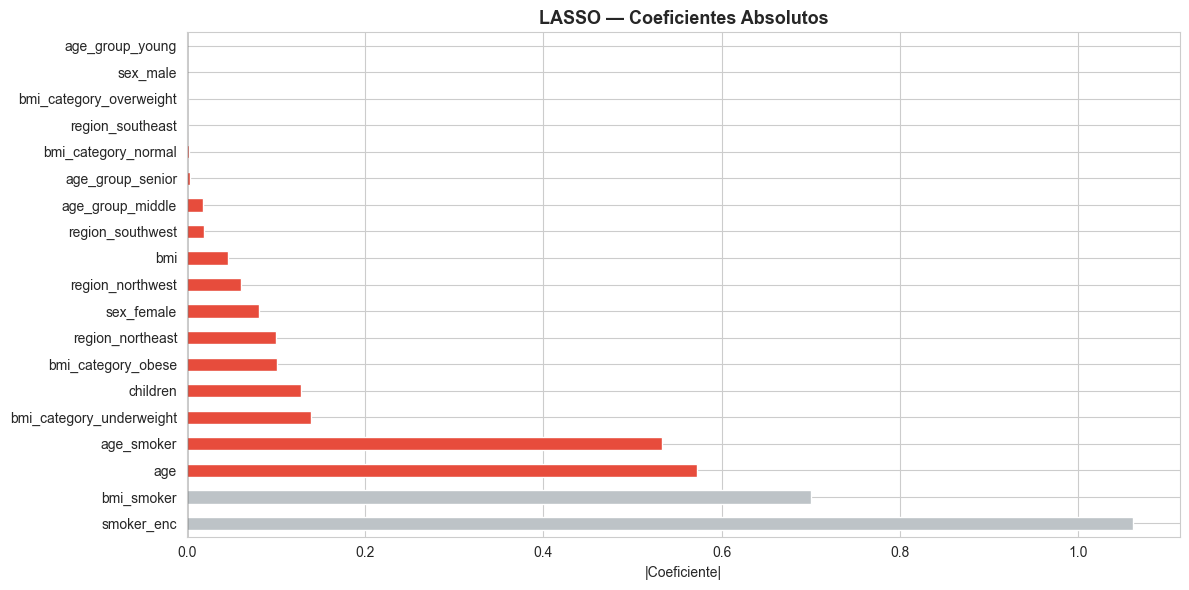

In [9]:
# ─────────────────────────────────────────
# LASSO (regularización L1)
# Los coeficientes en 0 indican features poco relevantes
# ─────────────────────────────────────────
lasso = Lasso(alpha=0.001, max_iter=10000, random_state=42)
lasso.fit(X_train_scaled, y_train)

lasso_coefs = pd.Series(
    np.abs(lasso.coef_), index=X_train.columns
).sort_values(ascending=False)

lasso_zero = lasso_coefs[lasso_coefs == 0].index.tolist()
lasso_nonzero = lasso_coefs[lasso_coefs > 0].index.tolist()

print(f'📊 LASSO con alpha=0.001:')
print(f'   Features con coef ≠ 0: {len(lasso_nonzero)}')
print(f'   Features eliminadas (coef=0): {len(lasso_zero)}')
if lasso_zero:
    print(f'   Features eliminadas: {lasso_zero}')

fig, ax = plt.subplots(figsize=(12, 6))
colors = ['#e74c3c' if v > 0 else '#bdc3c7' for v in lasso_coefs.values]
lasso_coefs.plot(kind='barh', ax=ax, color=colors[::-1], edgecolor='white')
ax.set_title('LASSO — Coeficientes Absolutos', fontsize=13, fontweight='bold')
ax.set_xlabel('|Coeficiente|')
ax.axvline(x=0, color='black', linewidth=1)
plt.tight_layout()
plt.savefig('../data/processed/lasso_feature_selection.png', dpi=150)
plt.show()

## 8. Síntesis: Ranking Combinado de Features

📊 RANKING COMBINADO DE FEATURES:
                          Pearson  MutualInfo  F_Score  RF_Importance   LASSO  SCORE_FINAL
bmi_smoker                 1.0000      0.3563   1.0000         0.8328  0.6595       0.7697
age                        0.7708      1.0000   0.4477         1.0000  0.5396       0.7516
smoker_enc                 0.9732      0.2442   0.9082         0.1331  1.0000       0.6517
age_smoker                 0.9382      0.3500   0.8024         0.2230  0.5024       0.5632
age_group_senior           0.6331      0.3032   0.2707         0.0024  0.0033       0.2425
age_group_young            0.6252      0.2570   0.2627         0.0017  0.0000       0.2293
children                   0.2555      0.1094   0.0381         0.1395  0.1204       0.1326
bmi                        0.1787      0.0447   0.0187         0.2060  0.0432       0.0983
bmi_category_obese         0.1797      0.0673   0.0189         0.0080  0.0954       0.0738
age_group_middle           0.0199      0.2298   0.0003   

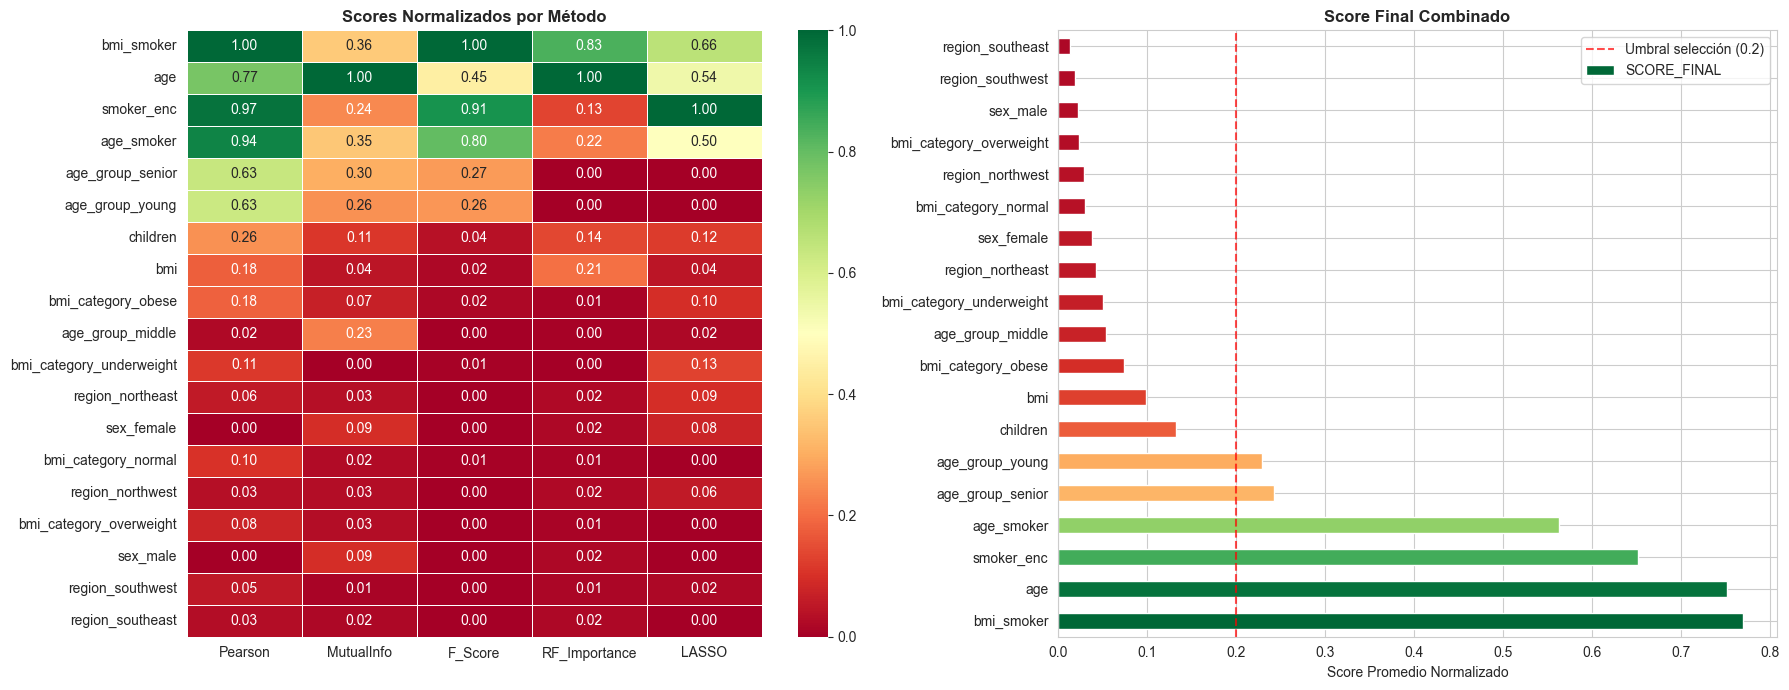

In [10]:
# ─────────────────────────────────────────
# RANKING COMBINADO — Promedio de rangos
# ─────────────────────────────────────────
features = list(X_train.columns)

# Normalizar cada método entre 0 y 1
def normalize(series):
    if series.max() == series.min():
        return series * 0
    return (series - series.min()) / (series.max() - series.min())

scores_df = pd.DataFrame({
    'Pearson':         normalize(pearson_corr.reindex(features).fillna(0)),
    'MutualInfo':      normalize(mi_series.reindex(features).fillna(0)),
    'F_Score':         normalize(f_scores['F_Score'].reindex(features).fillna(0)),
    'RF_Importance':   normalize(rf_importance.reindex(features).fillna(0)),
    'LASSO':           normalize(lasso_coefs.reindex(features).fillna(0)),
}, index=features)

scores_df['SCORE_FINAL'] = scores_df.mean(axis=1)
scores_df = scores_df.sort_values('SCORE_FINAL', ascending=False)

print('📊 RANKING COMBINADO DE FEATURES:')
print(scores_df.round(4).to_string())

# Visualización
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Heatmap de scores
sns.heatmap(scores_df.drop(columns='SCORE_FINAL'), annot=True, fmt='.2f',
            cmap='RdYlGn', ax=axes[0], linewidths=0.5)
axes[0].set_title('Scores Normalizados por Método', fontweight='bold')

# Score final
scores_df['SCORE_FINAL'].plot(kind='barh', ax=axes[1],
                               color=plt.cm.RdYlGn(scores_df['SCORE_FINAL'].values / scores_df['SCORE_FINAL'].max()),
                               edgecolor='white')
axes[1].set_title('Score Final Combinado', fontweight='bold')
axes[1].set_xlabel('Score Promedio Normalizado')
axes[1].axvline(x=0.2, color='red', linestyle='--', alpha=0.7, label='Umbral selección (0.2)')
axes[1].legend()

plt.tight_layout()
plt.savefig('../data/processed/combined_feature_ranking.png', dpi=150, bbox_inches='tight')
plt.show()

## 9. Selección Final de Features

In [11]:
# ─────────────────────────────────────────
# SELECCIÓN FINAL
# Umbral: score >= 0.2 Y estadísticamente significativa
# ─────────────────────────────────────────
THRESHOLD = 0.1
selected_features = scores_df[scores_df['SCORE_FINAL'] >= THRESHOLD].index.tolist()

# Asegurar que features clave siempre estén incluidas
mandatory = ['smoker_enc', 'age', 'bmi']
for feat in mandatory:
    if feat in X_train.columns and feat not in selected_features:
        selected_features.append(feat)

print(f' Features seleccionadas ({len(selected_features)}):')
for i, f in enumerate(selected_features, 1):
    score = scores_df.loc[f, 'SCORE_FINAL'] if f in scores_df.index else 'N/A'
    print(f'  {i:2d}. {f:35s} | Score: {score:.3f}' if isinstance(score, float) else f'  {i:2d}. {f}')

eliminated = [f for f in X_train.columns if f not in selected_features]
print(f'\n Features eliminadas ({len(eliminated)}):')
for f in eliminated:
    score = scores_df.loc[f, 'SCORE_FINAL'] if f in scores_df.index else 'N/A'
    print(f'     {f:35s} | Score: {score:.3f}' if isinstance(score, float) else f'     {f}')

 Features seleccionadas (8):
   1. bmi_smoker                          | Score: 0.770
   2. age                                 | Score: 0.752
   3. smoker_enc                          | Score: 0.652
   4. age_smoker                          | Score: 0.563
   5. age_group_senior                    | Score: 0.243
   6. age_group_young                     | Score: 0.229
   7. children                            | Score: 0.133
   8. bmi                                 | Score: 0.098

 Features eliminadas (11):
     sex_female                          | Score: 0.038
     sex_male                            | Score: 0.023
     region_northeast                    | Score: 0.042
     region_northwest                    | Score: 0.028
     region_southeast                    | Score: 0.013
     region_southwest                    | Score: 0.019
     bmi_category_underweight            | Score: 0.050
     bmi_category_normal                 | Score: 0.030
     bmi_category_overweight           

In [12]:
# ─────────────────────────────────────────
# GUARDAR DATASETS CON FEATURES SELECCIONADAS
# ─────────────────────────────────────────
X_train_selected = X_train[selected_features]
X_test_selected  = X_test[selected_features]
X_train_scaled_selected = X_train_scaled[selected_features]
X_test_scaled_selected  = X_test_scaled[selected_features]

X_train_selected.to_csv('../data/processed/X_train_selected.csv', index=False)
X_test_selected.to_csv('../data/processed/X_test_selected.csv', index=False)
X_train_scaled_selected.to_csv('../data/processed/X_train_scaled_selected.csv', index=False)
X_test_scaled_selected.to_csv('../data/processed/X_test_scaled_selected.csv', index=False)

# Guardar scores y features seleccionadas
scores_df.to_csv('../data/processed/feature_scores.csv')

feature_info['selected_features'] = selected_features
feature_info['eliminated_features'] = eliminated
feature_info['n_selected'] = len(selected_features)
with open('../data/processed/feature_info.json', 'w') as f:
    json.dump(feature_info, f, indent=2)

# Guardar el modelo RF para feature importance en la app
joblib.dump(rf_selector, '../models/rf_feature_selector.pkl')
joblib.dump(selected_features, '../models/selected_features.pkl')

print('✅ Datasets y artefactos guardados:')
print('  📁 data/processed/X_train_selected.csv')
print('  📁 data/processed/X_test_selected.csv')
print('  📁 data/processed/feature_scores.csv')
print('  📁 data/processed/feature_info.json (actualizado)')
print('  📁 models/rf_feature_selector.pkl')
print('  📁 models/selected_features.pkl')

✅ Datasets y artefactos guardados:
  📁 data/processed/X_train_selected.csv
  📁 data/processed/X_test_selected.csv
  📁 data/processed/feature_scores.csv
  📁 data/processed/feature_info.json (actualizado)
  📁 models/rf_feature_selector.pkl
  📁 models/selected_features.pkl


## 10. 📝 Conclusiones de Ingeniería de Características

### Hallazgos Clave:

1. **`smoker_enc`**, **`age`** y **`bmi_smoker`** (interacción BMI × Smoker) son las features más importantes

2. **`bmi_smoker`** (interacción BMI × Smoker) captura el efecto combinado de obesidad + tabaquismo, resultando muy predictivo, supera **`bmi`** por si sola en predicción

3. **`age`** y **`bmi`** tienen relación moderada pero estadísticamente significativa con charges

4. Las variables de región y sexo no aportan

5. Fueron conservadas 8 variables y eliminadas 11.